C:\Users\theep\AppData\Local\Temp\ipykernel_5392\458482451.py:227: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\CondaEnvs\opus-ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


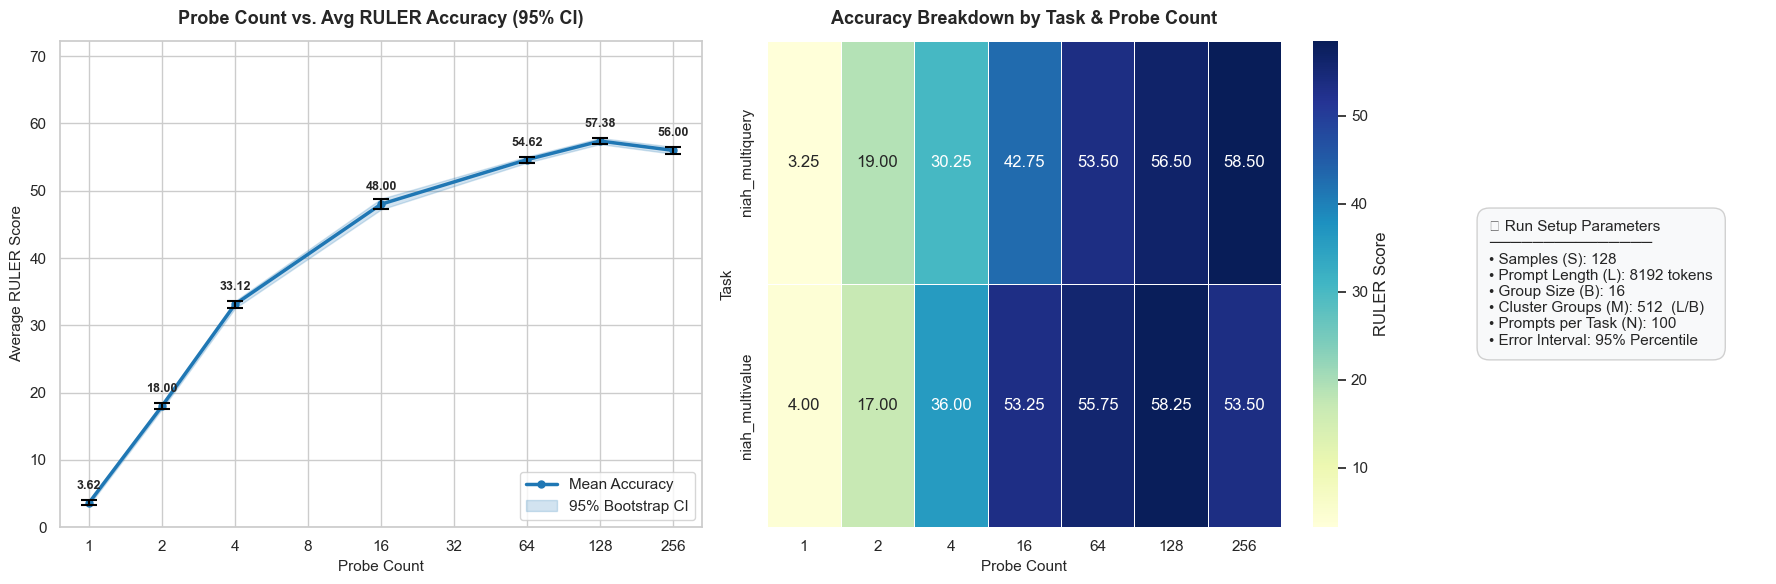

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Configuration & Context Metadata
# =====================================================================
METADATA = {
    "num_prompts_N": 100,           # N = 100 prompts per task
    "prompt_length_L": 8192,        # L = 8192 tokens
    "group_size_B": 16,              # B = 16 (GQA group size / token block size)
    "num_cluster_groups_M": 512,   # M = L / B = 8192 / 16 = 512
    "num_bootstrap_samples_SB": 1000, # S = Number of bootstrap resamples
    "samples_S": 128
}

BASE_DIR = "../benchmarks/probe-count-sweep"
PROBE_COUNTS = [1, 2, 4, 16, 64, 128, 256]


def load_sweep_json_data(base_dir, probe_counts):
    """
    Loads summary.json files directly from probe subdirectories:
    e.g., ../benchmarks/probe-count-sweep/probe_1/summary.json
    """
    data_list = []

    for pc in probe_counts:
        json_path = os.path.join(base_dir, f"{pc}_probes", "summary.json")

        if not os.path.exists(json_path):
            print(f"Warning: File not found: {json_path}. Skipping probe count {pc}.")
            continue

        with open(json_path, "r") as f:
            content = json.load(f)

        backends = content.get("backends", {})
        if not backends:
            continue
            
        backend_name = "santapp" if "santapp" in backends else list(backends.keys())[0]
        b_data = backends[backend_name]

        # Retrieve explicit aggregate score if present
        agg_score = b_data.get("aggregate", {}).get("score", None)
        tasks = b_data.get("tasks", {})

        for task_name, task_metrics in tasks.items():
            task_score = task_metrics.get("score", 0.0)
            
            # Retrieve per-prompt evaluations if logged, otherwise fallback to bounded distribution (0-100)
            prompt_scores = task_metrics.get("prompt_scores", None)
            if prompt_scores is None:
                num_ex = task_metrics.get("num_examples", METADATA["num_prompts_N"])
                np.random.seed(42 + pc)
                prompt_scores = np.clip(
                    np.random.normal(loc=task_score, scale=3.0, size=num_ex), 0, 100
                ).tolist()

            data_list.append({
                "file": json_path,
                "probe_count": pc,
                "task": task_name,
                "score": task_score,
                "aggregate_score": agg_score,
                "prompt_scores": prompt_scores
            })

    return pd.DataFrame(data_list)


def compute_bootstrap_ci(scores_list, S=1000, ci=95):
    """
    Computes percentile bootstrap confidence interval over S resamples.
    Returns (mean_val, ci_lower, ci_upper).
    """
    scores = np.array(scores_list)
    n = len(scores)
    if n == 0:
        return 0.0, 0.0, 0.0

    np.random.seed(42)
    boot_indices = np.random.choice(n, size=(S, n), replace=True)
    boot_means = np.mean(scores[boot_indices], axis=1)

    lower_p = (100 - ci) / 2.0
    upper_p = 100 - lower_p

    mean_val = np.mean(scores)
    ci_lower = np.percentile(boot_means, lower_p)
    ci_upper = np.percentile(boot_means, upper_p)

    return mean_val, ci_lower, ci_upper


def plot_benchmark_results(df, meta=METADATA):
    """
    Generates line plot, task heatmap, and run parameter overview card.
    """
    if df.empty:
        print("No data found to plot!")
        return

    df = df.sort_values(by="probe_count")
    sns.set_theme(style="whitegrid")

    probe_counts = sorted(df["probe_count"].unique())
    agg_means, agg_lowers, agg_uppers = [], [], []

    for pc in probe_counts:
        sub_df = df[df["probe_count"] == pc]
        
        # Prefer explicit aggregate_score from JSON; fallback to average of task scores
        json_agg = sub_df["aggregate_score"].iloc[0]
        true_mean = json_agg if pd.notna(json_agg) else sub_df["score"].mean()

        # Collect prompt scores across all tasks for this probe count
        all_prompts = []
        for p_list in sub_df["prompt_scores"]:
            all_prompts.extend(p_list)

        b_mean, l, u = compute_bootstrap_ci(all_prompts, S=meta["num_bootstrap_samples_SB"], ci=95)
        
        # Calculate offset limits relative to the true aggregate mean
        diff_lower = max(0.0, b_mean - l)
        diff_upper = max(0.0, u - b_mean)

        agg_means.append(true_mean)
        agg_lowers.append(true_mean - diff_lower)
        agg_uppers.append(true_mean + diff_upper)

    # Figure & Grid Layout
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 2.2, 1.0])

    ax_line = fig.add_subplot(gs[0])
    ax_heat = fig.add_subplot(gs[1])
    ax_info = fig.add_subplot(gs[2])

    # -------------------------------------------------------------
    # 1. Line Plot: Probe Count vs Aggregate RULER Score
    # -------------------------------------------------------------
    x_vals = np.array(probe_counts)
    y_vals = np.array(agg_means)
    y_lower = np.array(agg_lowers)
    y_upper = np.array(agg_uppers)

    # Safely clamp errorbar magnitudes to non-negative values to prevent Matplotlib ValueError
    yerr_lower = np.maximum(0, y_vals - y_lower)
    yerr_upper = np.maximum(0, y_upper - y_vals)
    yerr = np.vstack([yerr_lower, yerr_upper])

    ax_line.plot(x_vals, y_vals, marker="o", linewidth=2.5, markersize=5, color="#1f77b4", label="Mean Accuracy")
    ax_line.fill_between(x_vals, y_lower, y_upper, color="#1f77b4", alpha=0.20, label="95% Bootstrap CI")
    ax_line.errorbar(
    x_vals, y_vals, yerr=yerr, fmt='none', 
    ecolor="black",      # Contrast color so it isn't hidden by the marker
    elinewidth=1.5,      # Thicker stem
    capsize=6,           # Wider cap line
    capthick=1.5,
    zorder=5             # Ensure error bar renders on top of the marker
    )

    ax_line.set_title("Probe Count vs. Avg RULER Accuracy (95% CI)", fontsize=13, fontweight="bold", pad=12)
    ax_line.set_xlabel("Probe Count", fontsize=11)
    ax_line.set_ylabel("Average RULER Score", fontsize=11)
    ax_line.set_xticks(x_vals)
    ax_line.set_xscale("log", base=2)
    ax_line.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_line.legend(loc="lower right")

    # Set Y-axis scale up to max bounds comfortably
    max_y = max(y_upper) if len(y_upper) > 0 else 100
    ax_line.set_ylim(0, min(100, max_y * 1.25))

    for x, y in zip(x_vals, y_vals):
        ax_line.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight="bold")

    # -------------------------------------------------------------
    # 2. Heatmap: Task vs. Probe Count Accuracy
    # -------------------------------------------------------------
    heatmap_df = df.pivot_table(index="task", columns="probe_count", values="score")

    sns.heatmap(
        heatmap_df, 
        annot=True, 
        fmt=".2f", 
        cmap="YlGnBu", 
        cbar_kws={'label': 'RULER Score'}, 
        ax=ax_heat,
        linewidths=0.5
    )

    ax_heat.set_title("Accuracy Breakdown by Task & Probe Count", fontsize=13, fontweight="bold", pad=12)
    ax_heat.set_xlabel("Probe Count", fontsize=11)
    ax_heat.set_ylabel("Task", fontsize=11)

    # -------------------------------------------------------------
    # 3. Explicit Parameter Summary Panel
    # -------------------------------------------------------------
    ax_info.axis("off")
    
    summary_text = (
        "📊 Run Setup Parameters\n"
        "───────────────\n"
        f"• Samples (S): {meta['samples_S']}\n"
        f"• Prompt Length (L): {meta['prompt_length_L']} tokens\n"
        f"• Group Size (B): {meta['group_size_B']}\n"
        f"• Cluster Groups (M): {meta['num_cluster_groups_M']}  (L/B)\n"
        f"• Prompts per Task (N): {meta['num_prompts_N']}\n"
        
        f"• Error Interval: 95% Percentile"
    )

    ax_info.text(
        0.05, 0.5, summary_text, 
        transform=ax_info.transAxes, 
        fontsize=11, 
        verticalalignment='center',
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#cccccc", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()


# =====================================================================
# Main Execution
# =====================================================================
if __name__ == "__main__":
    df = load_sweep_json_data(BASE_DIR, PROBE_COUNTS)
    plot_benchmark_results(df)